# 3D Print Failure Prediction — Logistic Regression 
**Cornell Tech MakerLAB Project**

Implements logistic regression from scratch (NumPy only) with weighted loss, validation tuning, and final test evaluation.

In [8]:
import sys
sys.path.append("..")

import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from src.logistic_regression import LogisticRegression

DATA_DIR = "../data/raw/processed"
MODEL_OUT = "../data/raw/processed/lr_weights.pkl"

## 1. Load preprocessed data

In [9]:
train = np.load(f"{DATA_DIR}/train.npz")
val   = np.load(f"{DATA_DIR}/val.npz")
test  = np.load(f"{DATA_DIR}/test.npz")

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

with open(f"{DATA_DIR}/feature_cols.json") as f:
    feature_cols = json.load(f)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Class dist (train) — 0:", (y_train==0).sum(), "| 1:", (y_train==1).sum())

Train: (700, 20) | Val: (150, 20) | Test: (150, 20)
Class dist (train) — 0: 253 | 1: 447


## 2. Hyperparameter tuning on validation set

Grid search over learning rate and number of iterations. We tune only on `val.npz` — `test.npz` is untouched until final evaluation.

In [10]:
def f1_score_binary(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    return 2 * precision * recall / (precision + recall + 1e-12)

lr_grid     = [0.001, 0.01, 0.05, 0.1]
iter_grid   = [500, 1000, 2000]

best_f1, best_lr, best_n_iter = 0, None, None
results = []

for lr in lr_grid:
    for n_iter in iter_grid:
        model = LogisticRegression(lr=lr, n_iter=n_iter)
        model.fit(X_train, y_train, class_weight="balanced")
        y_pred_val = model.predict(X_val)
        f1 = f1_score_binary(y_val, y_pred_val)
        acc = (y_pred_val == y_val).mean()
        results.append({"lr": lr, "n_iter": n_iter, "val_f1": f1, "val_acc": acc})
        if f1 > best_f1:
            best_f1, best_lr, best_n_iter = f1, lr, n_iter

print(f"Best val F1: {best_f1:.4f}  |  lr={best_lr}  |  n_iter={best_n_iter}")

Best val F1: 0.8889  |  lr=0.001  |  n_iter=2000


## 3. Train final model with best hyperparameters

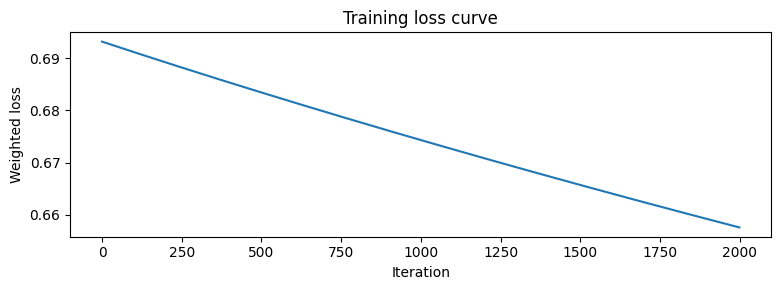

In [11]:
final_model = LogisticRegression(lr=best_lr, n_iter=best_n_iter)
final_model.fit(X_train, y_train, class_weight="balanced")

plt.figure(figsize=(8, 3))
plt.plot(final_model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Weighted loss")
plt.title("Training loss curve")
plt.tight_layout()
plt.show()

## 4. Final evaluation on test set

In [12]:
def full_report(y_true, y_pred, split="Test"):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    acc       = (y_pred == y_true).mean()
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)
    print(f"--- {split} metrics ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Confusion matrix:\n  TP={tp} FP={fp}\n  FN={fn} TN={tn}")

y_pred_test = final_model.predict(X_test)
full_report(y_test, y_pred_test, split="Test")

--- Test metrics ---
Accuracy:  0.8067
Precision: 0.8190
Recall:    0.8958
F1:        0.8557
Confusion matrix:
  TP=86 FP=19
  FN=10 TN=35


## 4b. Threshold tuning — optimize for recall

Default threshold is 0.5. For a failure-prediction safety tool, we want to minimize false negatives (missed failures). We sweep thresholds on the **val set** and pick the one that maximizes recall while keeping precision reasonable.

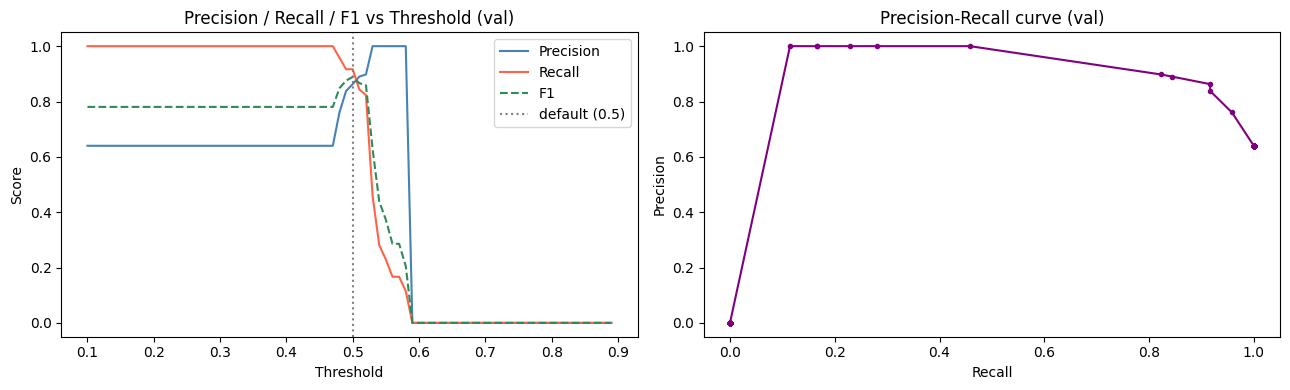

In [13]:
thresholds = np.arange(0.1, 0.9, 0.01)
val_proba = final_model.predict_proba(X_val)

precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred = (val_proba >= t).astype(int)
    tp = ((y_pred == 1) & (y_val == 1)).sum()
    fp = ((y_pred == 1) & (y_val == 0)).sum()
    fn = ((y_pred == 0) & (y_val == 1)).sum()
    p = tp / (tp + fp + 1e-12)
    r = tp / (tp + fn + 1e-12)
    f = 2 * p * r / (p + r + 1e-12)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# precision / recall / f1 vs threshold
axes[0].plot(thresholds, precisions, label="Precision", color="steelblue")
axes[0].plot(thresholds, recalls,    label="Recall",    color="tomato")
axes[0].plot(thresholds, f1s,        label="F1",        color="seagreen", linestyle="--")
axes[0].axvline(0.5, color="gray", linestyle=":", label="default (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold (val)")
axes[0].legend()

# precision-recall curve
axes[1].plot(recalls, precisions, color="purple", marker=".")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (val)")

plt.tight_layout()
plt.show()

In [14]:
# Pick threshold: highest F1 where recall >= 0.95
target_recall = 0.95
candidates = [(t, f, p, r) for t, f, p, r in zip(thresholds, f1s, precisions, recalls) if r >= target_recall]

if candidates:
    best = max(candidates, key=lambda x: x[1])
    best_threshold, best_f1_t, best_prec_t, best_rec_t = best
    print(f"Best threshold for recall >= {target_recall}: {best_threshold:.2f}")
    print(f"  Val — Precision: {best_prec_t:.4f}  Recall: {best_rec_t:.4f}  F1: {best_f1_t:.4f}")
else:
    print(f"No threshold achieves recall >= {target_recall} on val set.")
    best_threshold = 0.5

Best threshold for recall >= 0.95: 0.48
  Val — Precision: 0.7603  Recall: 0.9583  F1: 0.8479


### Re-evaluate on test set with tuned threshold

In [15]:
test_proba = final_model.predict_proba(X_test)
y_pred_tuned = (test_proba >= best_threshold).astype(int)

print(f"Threshold: {best_threshold:.2f}  (default was 0.50)\n")
print("--- Default threshold (0.50) ---")
full_report(y_test, y_pred_test, split="Test")
print()
print(f"--- Tuned threshold ({best_threshold:.2f}) ---")
full_report(y_test, y_pred_tuned, split="Test")

Threshold: 0.48  (default was 0.50)

--- Default threshold (0.50) ---
--- Test metrics ---
Accuracy:  0.8067
Precision: 0.8190
Recall:    0.8958
F1:        0.8557
Confusion matrix:
  TP=86 FP=19
  FN=10 TN=35

--- Tuned threshold (0.48) ---
--- Test metrics ---
Accuracy:  0.7600
Precision: 0.7381
Recall:    0.9687
F1:        0.8378
Confusion matrix:
  TP=93 FP=33
  FN=3 TN=21


## 5. Feature importance (learned weights)

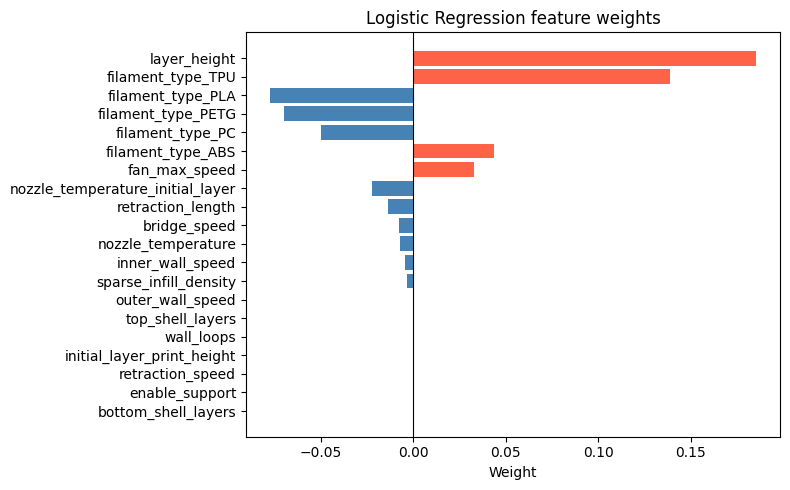

In [16]:
sorted_idx = np.argsort(np.abs(final_model.weights))[::-1]
sorted_weights = final_model.weights[sorted_idx]
sorted_features = [feature_cols[i] for i in sorted_idx]

plt.figure(figsize=(8, 5))
colors = ["tomato" if w > 0 else "steelblue" for w in sorted_weights]
plt.barh(sorted_features[::-1], sorted_weights[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weight")
plt.title("Logistic Regression feature weights")
plt.tight_layout()
plt.show()

## 6. Save model weights → `lr_weights.pkl`

In [ ]:
with open(MODEL_OUT, "wb") as f:
    pickle.dump({
        "weights":   final_model.weights,
        "bias":      final_model.bias,
        "threshold": best_threshold,
    }, f)

print(f"Saved to {MODEL_OUT}")
print(f"weights shape: {final_model.weights.shape}, bias: {final_model.bias:.6f}, threshold: {best_threshold:.2f}")